In [1]:
ls -lh ./tmpignore/

do_ypcall: clnt_call: RPC: Timed out
total 262M
drwxrwxr-x 2 was966 was966 4.0K Mar 17 20:41 conceptor/
-rw-rw-r-- 1 was966 was966  34M Mar 17 23:56 finetuner_all_40.pt
-rw-rw-r-- 1 was966 was966  34M Mar 17 23:00 finetuner_all_50.pt
-rw-rw-r-- 1 was966 was966  34M Mar 18 00:24 finetuner_without_gide.pt
-rw-rw-r-- 1 was966 was966  769 Mar 17 20:19 gene_zip.ipynb
-rw-rw-r-- 1 was966 was966 1.1M Mar 17 20:47 ITRP.PATIENT.TABLE
-rw-rw-r-- 1 was966 was966 136M Mar 17 20:48 ITRP.TPM.TABLE
-rw-rw-r-- 1 was966 was966  26M Mar 17 20:47 pretrainer.pt


In [3]:
import os
from tqdm import tqdm
from itertools import chain
import pandas as pd
import numpy as np
import random, torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'white', font_scale=1.3)
import warnings
warnings.filterwarnings("ignore")

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd

## load pretrainer and the datasets

In [4]:
## load pretrainer
pretrainer = loadccompass('https://www.immuno-compass.com/download/model/pretrainer.pt')

## read data
df_label = pd.read_pickle('./tmpignore/ITRP.PATIENT.TABLE')
df_tpm = pd.read_pickle('./tmpignore/ITRP.TPM.TABLE')
df_tpm.shape, df_label.shape

((1133, 15672), (1133, 110))

In [5]:
train_idx = df_label[df_label.cohort != 'Gide'].index
test_idx = df_label[df_label.cohort == 'Gide'].index

In [6]:
df_tpm.head()

,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,AADAT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Index,,,,,,,,,,,,,,,,,,,,,
IMVigor210-0257bb-ar-0257bbb,0.205851,2.155888,659.745279,20.704149,7.936608,0.000000,82.356025,6.818171,1.341996,8.806979,...,19.827670,35.762746,3.052251,4.759638,23.932628,0.353733,53.545112,33.434797,63.913951,21.918333
IMVigor210-025b45-ar-025b45c,1.868506,0.000000,368.595425,7.356325,14.221725,0.012419,66.000702,16.410020,74.672523,9.551180,...,21.562821,7.727498,2.840277,4.399035,10.118828,0.425108,30.963466,87.048508,50.694129,15.833533
IMVigor210-032c64-ar-032c642,0.074416,0.023730,194.673484,1.016972,58.998834,0.012352,105.698176,15.143666,0.028117,2.441625,...,28.428787,29.953545,3.286946,4.307672,13.970757,1.582359,19.573847,94.128930,47.873491,10.933422
IMVigor210-0571f1-ar-0571f17,2.306056,0.000000,325.709796,18.747406,10.965047,0.018950,76.854569,7.491749,0.043138,7.001308,...,23.462814,18.647978,5.777748,5.938934,12.687338,1.001439,20.971129,50.101555,78.684380,14.659834
IMVigor210-065890-ar-0658907,0.000000,0.024102,182.904400,23.246839,3.457102,0.000000,66.561993,14.851419,120.742181,25.713897,...,30.468925,16.782164,4.356220,7.165276,17.453367,0.552250,33.347260,20.544651,41.852786,18.699320


In [7]:
dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
df_task = onehot(df_label.response_label)
dfcx.head()

,cancer_code,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Index,,,,,,,,,,,,,,,,,,,,,
IMVigor210-0257bb-ar-0257bbb,1,0.205851,2.155888,659.745279,20.704149,7.936608,0.000000,82.356025,6.818171,1.341996,...,19.827670,35.762746,3.052251,4.759638,23.932628,0.353733,53.545112,33.434797,63.913951,21.918333
IMVigor210-025b45-ar-025b45c,1,1.868506,0.000000,368.595425,7.356325,14.221725,0.012419,66.000702,16.410020,74.672523,...,21.562821,7.727498,2.840277,4.399035,10.118828,0.425108,30.963466,87.048508,50.694129,15.833533
IMVigor210-032c64-ar-032c642,1,0.074416,0.023730,194.673484,1.016972,58.998834,0.012352,105.698176,15.143666,0.028117,...,28.428787,29.953545,3.286946,4.307672,13.970757,1.582359,19.573847,94.128930,47.873491,10.933422
IMVigor210-0571f1-ar-0571f17,1,2.306056,0.000000,325.709796,18.747406,10.965047,0.018950,76.854569,7.491749,0.043138,...,23.462814,18.647978,5.777748,5.938934,12.687338,1.001439,20.971129,50.101555,78.684380,14.659834
IMVigor210-065890-ar-0658907,1,0.000000,0.024102,182.904400,23.246839,3.457102,0.000000,66.561993,14.851419,120.742181,...,30.468925,16.782164,4.356220,7.165276,17.453367,0.552250,33.347260,20.544651,41.852786,18.699320


In [8]:
df_task.head()

,NR,R
Index,,
IMVigor210-0257bb-ar-0257bbb,1.0,0.0
IMVigor210-025b45-ar-025b45c,1.0,0.0
IMVigor210-032c64-ar-032c642,1.0,0.0
IMVigor210-0571f1-ar-0571f17,1.0,0.0
IMVigor210-065890-ar-0658907,0.0,1.0


In [10]:
dfcx_train = dfcx.loc[train_idx]
dfy_train = df_task.loc[train_idx]

dfcx_test = dfcx.loc[test_idx]
dfy_test = df_task.loc[test_idx]

print(len(dfcx_train), len(dfcx_test))

1060 73


## Initialize and perform fine-tuning
finetuning parameters

In [ ]:
params = {'mode': 'PFT',
        'seed':42,
        'lr': 1e-2,
        'device':'cuda',
        'weight_decay': 1e-3,
        'batch_size':32, 
        'max_epochs': 20,
        'with_wandb': False,
        'save_best_model':False,
        'verbose': False}

In [11]:
finetuner = FineTuner(pretrainer, **params)
finetuner = finetuner.tune(dfcx_train = dfcx_train, dfy_train = dfy_train)

100%|##########| 20/20 [10:32<00:00, 31.63s/it]


In [12]:
finetuner.save('./tmpignore/finetuner_without_gide.pt')

Saving the model to ./tmpignore/finetuner_without_gide.pt


## Evaluate the model performance

In [13]:
dfe, df_pred = finetuner.predict(dfcx_test, batch_size = 16)

100%|##########| 5/5 [00:00<00:00,  6.67it/s]


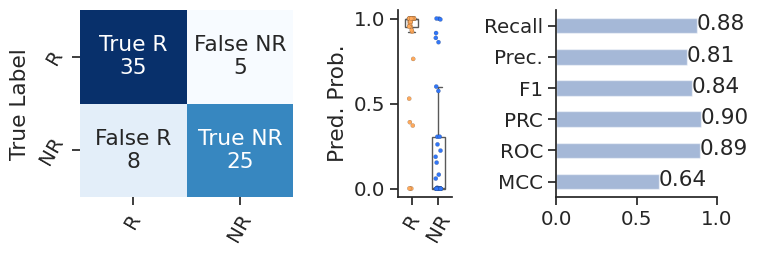

In [14]:
dfp = dfy_test.join(df_pred)
y_true, y_prob, y_pred = dfp['R'], dfp[1], dfp[[0, 1]].idxmax(axis=1)
fig = plot_performance(y_true, y_prob, y_pred)

<Axes: xlabel='epoch'>

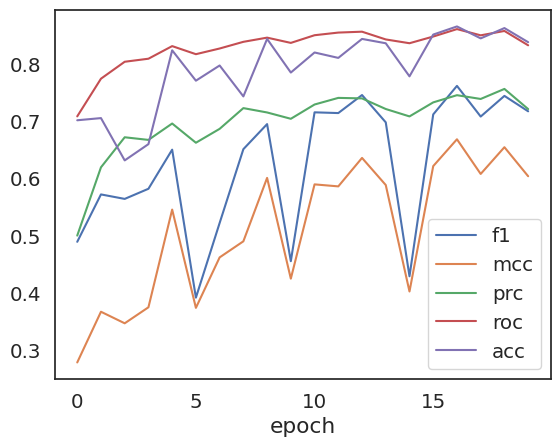

In [15]:
pd.DataFrame(finetuner.performance,
             columns = ['epoch', 'f1', 'mcc', 'prc', 'roc', 'acc']).set_index('epoch').plot()

In [16]:
finetuner.best_epoch

17